# Post-processing chain

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [1]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.starquery  as sq
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

 "IMPORTANT: The GACS archive will be down from April 18, 2024, 16:30 CEST until April 23, 2024, 08:30 CEST."


In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'

## *Example of photometry*

In [471]:
# Set up a Simulation object
sim = Simulation("output_photometry", outputDir=os.getcwd())

# Download files from KUL FTP site:
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
# ut.downloadFromFTP(filename="varsource_gdor.txt",  outputDir=os.getcwd(), server='plato')
# ut.downloadFromFTP(filename="varsource_algol.txt", outputDir=os.getcwd(), server='plato')
# ut.downloadFromFTP(filename="varsource_ap.txt",    outputDir=os.getcwd(), server='plato')

# Load variable source files
variableSourceFile0 = inputDir + "/varsource_gdor.txt"
variableSourceFile1 = inputDir + "/varsource_algol.txt"
variableSourceFile2 = inputDir + "/varsource_ap.txt"

# Load files
var0 = np.loadtxt(variableSourceFile0)
var1 = np.loadtxt(variableSourceFile1)
var2 = np.loadtxt(variableSourceFile2)

<IPython.core.display.Javascript object>


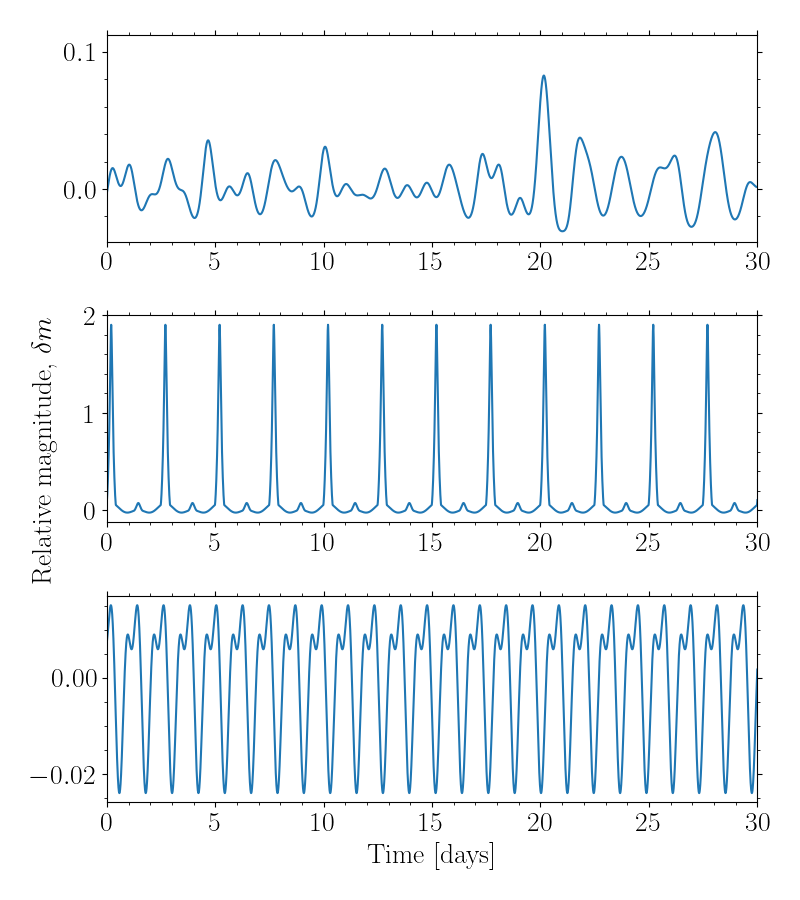

In [472]:
# Show noise-less light curves
fig, ax = plt.subplots(3, 1, figsize=(8,9))
for i, var in zip(range(3), [var0, var1, var2]):
    time = var[:,0]/86400
    ax[i].plot(time, var[:,1])
    ax[i].set_xlim(time[0], 30)
fig.text(0.04, 0.5, 'Relative magnitude, $\delta m$', va='center', rotation='vertical')
ax[2].set_xlabel('Time [days]')
plt.tight_layout()

In [473]:
# Automatic catalogue file creation
starID = [0, 1, 2]
variableSourceFiles = [variableSourceFile0, variableSourceFile1, variableSourceFile2]
variableSourceList  = os.getcwd() + "/varlist_photometry.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

# Select subfield size and location
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([3.0, 2.1, 4.3]) + sim["SubField/ZeroPointRow"]
col = np.array([3.0, 1.8, 5.2]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0, 12.0, 11.0])

# Automatic catalogue file creation
starcatFile = os.getcwd() + "/starcat_photometry.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Automatic photometry file creation
starID = [0]
photometryFile = os.getcwd() + "/photometry_example1.txt"
sim.createPhotometryFile(starID, photometryFile)

# Turn off saving 
sim.turnOffAllOutput()
sim["Sky/IncludeCosmicsInSubField"]    = False

# Control HDF5
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Activate photometry
sim["Photometry/IncludePhotometry"] = True
sim["Photometry/TargetFileName"]    = photometryFile

<IPython.core.display.Javascript object>


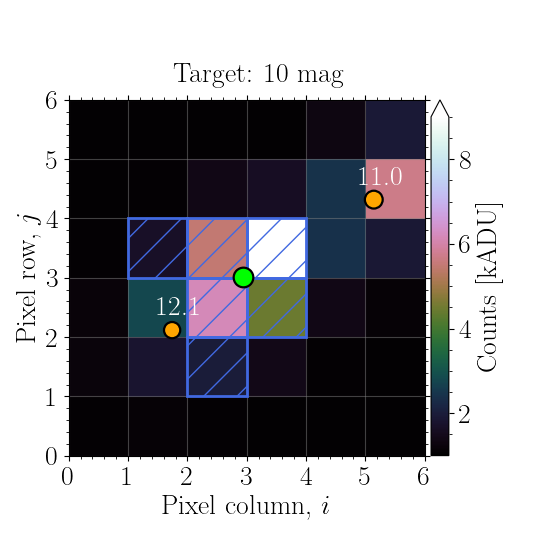

In [478]:
# Show imagette
sim["ObservingParameters/NumExposures"] = 1
f0 = sim.run(removeOutputFile=True)
fig, ax = f0.showImage(imgScale="percentile", clip=1, fontSize=20, count='kADU',
                       figsize=(5.5,5.5), showStarPositions='PIC', origin='lower',
                       colorBar=True, showGrid=True, showMaskOfStarID=0)
# fig.text(0.47, 0.85, 'a) Imagette', ha='center')
fig.text(0.47, 0.85, 'Target: 10 mag', ha='center')
# Save figure
fig.savefig(f'{fdir}/Imagette.png', bbox_inches='tight', dpi=200)

In [9]:
# Run the simulation
sim["ObservingParameters/NumExposures"] = int(10*86400/25.)
f1 = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:01:43.497739 [hh:mm:ss]


<IPython.core.display.Javascript object>


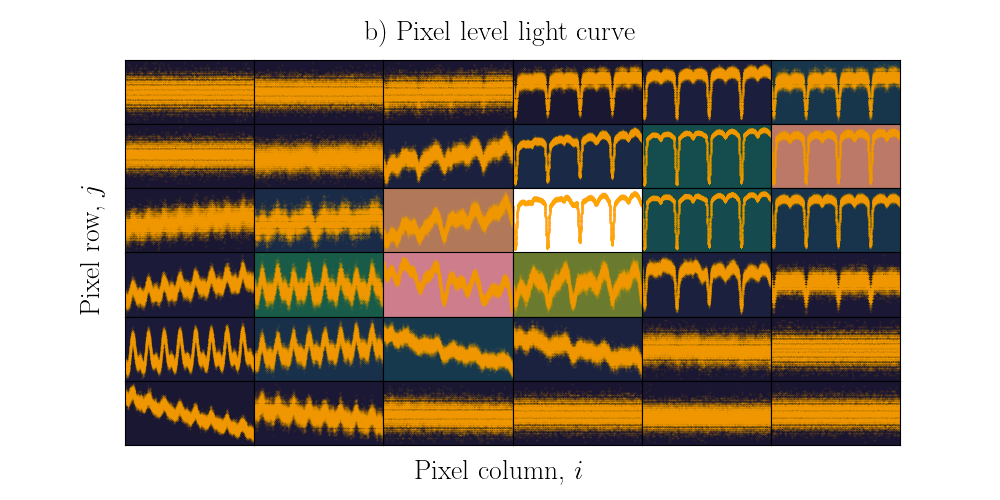

In [11]:
fig = f1.showPixelLevelLightCurve()
fig.text(0.5, 0.92, 'b) Pixel level light curve', ha='center')
# Save figure
fig.savefig(f'{fdir}/PixelLevelLightCurve.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


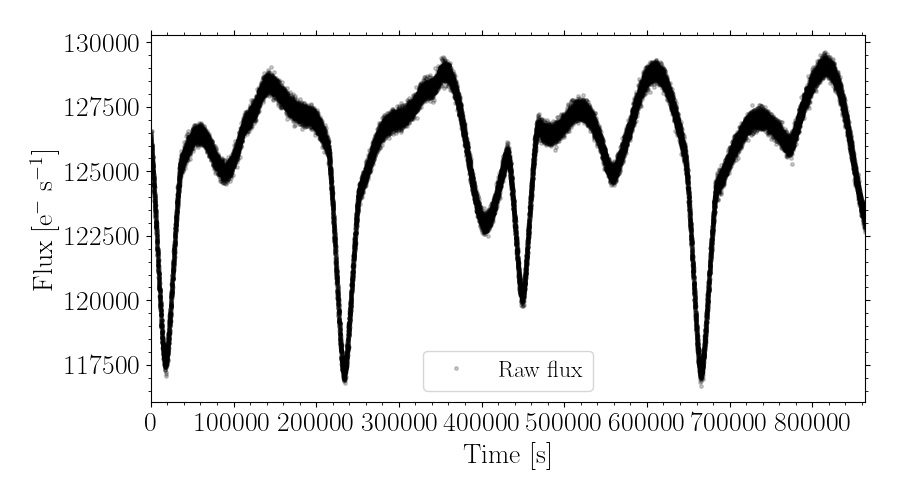

In [12]:
f1.plotLightCurve(0);

---
## Test poly-detrend model comparison
---

In [103]:
path = '/lhome/nicholas/software/workdir/mocka_affogato'
filename = f'{path}/test_hdf5/output/000000001/000000001_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000005/000000005_Ncam4.1_Q3.hdf5'

lc = LightCurve(filename)

In [101]:
# Data
df = lc.data()
df = df.loc[:int(30*86400/25)]
df = df.rename(columns={'time':'x', 'flux':'y'})

# Test models
model1 = 'y ~ x'
model2 = 'y ~ x + I(x**2)'
model3 = 'y ~ x + I(x**2) + I(x**3)'
fit1 = sm.OLS.from_formula(formula=model1, data=df).fit()
fit2 = sm.OLS.from_formula(formula=model2, data=df).fit()
fit3 = sm.OLS.from_formula(formula=model3, data=df).fit()
# fit1.summary()

In [104]:
# # Show procedure of model comparison
# st.plot_modelfit(df, fit1, model1, theme='b')
# st.plot_modelfit(df, fit2, model2, theme='g')
# st.plot_modelfit(df, fit3, model3, theme='r')
# AIC_j = [fit1.aic, fit2.aic, fit3.aic]
# BIC_j = [fit1.bic, fit2.bic, fit3.bic]
# st.model_selection(AIC_j, BIC_j, method='BIC', show=True);

---
## Test post-processing steps (HDF5)
---

In [6]:
# sim = Simulation('test.hdf5') 
# beginExposureNr = int(315569*(int(filename[-6])-1))
# numExposures    = 312113

# # Transient correction
# inputFileCCD = f'{idir}/instrumentGTT.txt'
# dt = pd.read_csv(inputFileCCD, sep=' ', names=['time', 'temp'])
# dt = dt.iloc[beginExposureNr:beginExposureNr+numExposures]
# temp = dt.temp.to_numpy()
# inputFileGap = f'{idir}/instrumentGAP.tab'
# dg = pd.read_feather(inputFileGap)
# tdur = dg.td.iloc[0] / 86400
# tempNominal   = sim['CCD/NominalOperatingTemperature']
# gainCCD       = sim['CCD/Gain/RefValueRight']
# gainFEE       = sim['FEE/Gain/RefValueRight']
# gainStability = sim['FEE/Gain/Stability']
# df = lc.correct_gain(temp, tdur, tempNominal, gainCCD, gainFEE, gainStability, replace=True, plot=True)

In [17]:
path = '/lhome/nicholas/software/workdir/mocka_affogato/test_hdf5'
path = '/lhome/nicholas/software/workdir/mocka_affogato/output'
filename = f'{path}/000000001/000000001_Ncam1.1_Q5.hdf5' # [1, 5]

lc = LightCurve(filename)
lc.star()

ID                           1
gaiaDR3    5303370405309247872
ra                  133.456062
dec                 -58.724099
mag                        8.5
group                        1
camera                       1
quarter                      5
ccd                          2
xCCD               1978.810204
yCCD               1154.518536
rOA                  16.197752
xFP                 -61.698666
yFP                 -36.918584
ncon                         1
SPR                   0.003884
Name: 0, dtype: object

<IPython.core.display.Javascript object>


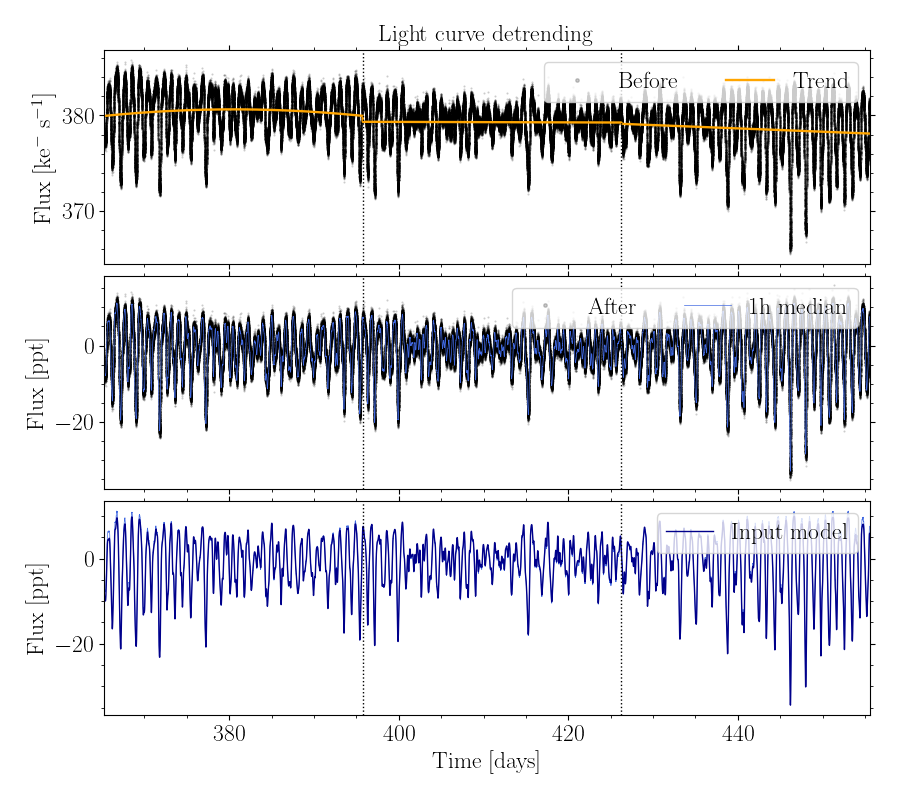

In [18]:
df = lc.detrend(model='poly', replace=True, plot=True)

<IPython.core.display.Javascript object>


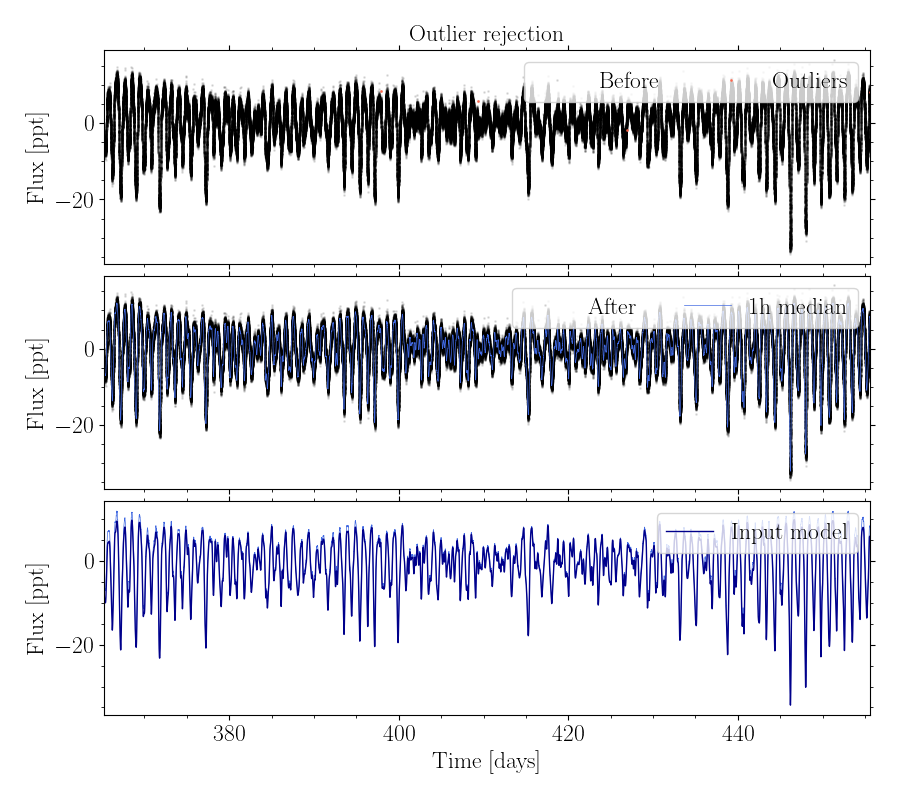

In [19]:
df = lc.clip(model='wotan', flux_unit='ppt', sigma_lower=5, sigma_upper=5, replace=True, plot=True)

In [161]:
# lc.stitch(method='lowess', segment=30, replace=True, plot=True);

---
## Check single reduced light curve (feather)
---

In [42]:
path = '/lhome/nicholas/software/workdir/mocka_affogato/test_vsc/output'

# filename = f'{path}/000000001/000000001_Ncam1.1_Q1.ftr'
filename = f'{path}/000004501/000004501_Ncam1.1_Q1.ftr'

lc = LightCurve(filename, mode="single")

In [113]:
# # Introduce gaps from file
# inputFileGap = f'{path}/input/instrumentGAP.ftr'
# df = lc.gaps(inputFileGap, beginExposureNr, numExposures, replace=True, plot=False)

<IPython.core.display.Javascript object>


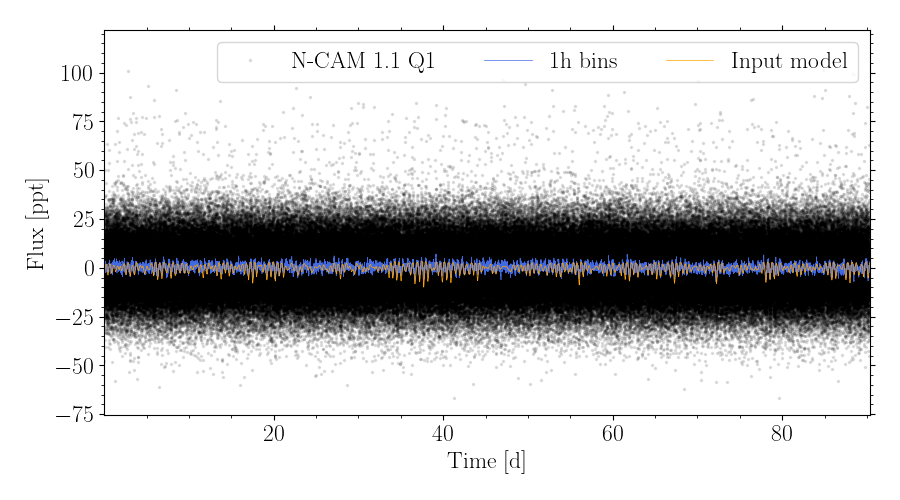

In [43]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=True, alpha=0.1);

---
## Test merging of light curves
---

In [136]:
path = '/lhome/nicholas/software/workdir/mocka_affogato/test_vsc'
star = '000000001'
# star = '000004501'
# star = '000004502'

fdir = f'{path}/{star}'
lcs = LightCurve(fdir, 'multi')

In [130]:
lcs.unpack()

In [138]:
df = lcs.stat_sim_table(ofile=f'{fdir}/lc_{star}.tab', clean=True)
df.head()

Creating simulation table:


100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.14


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,5303370405309247872,133.456062,-58.724099,13.936833,1,1,1,2,1978.731278,1154.424860,16.197905,-61.700353,-36.917163,4,0.225526
1,1,5303370405309247872,133.456062,-58.724099,13.936833,1,1,5,2,1978.810204,1154.518536,16.197752,-61.698666,-36.918584,4,0.230955
2,1,5303370405309247872,133.456062,-58.724099,13.936833,1,2,1,2,1965.086644,1167.098593,16.129187,-61.472225,-36.671560,4,0.234495
3,1,5303370405309247872,133.456062,-58.724099,13.936833,1,2,5,2,1965.165534,1167.192213,16.129033,-61.470540,-36.672980,4,0.252066
4,1,5303370405309247872,133.456062,-58.724099,13.936833,1,3,1,2,1974.073655,1155.038474,16.186699,-61.689307,-36.833326,4,0.238836


<IPython.core.display.Javascript object>


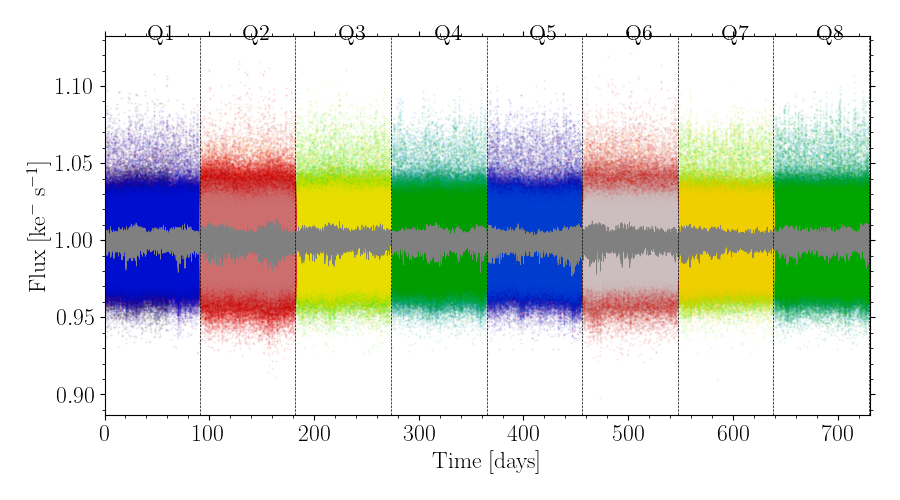

In [135]:
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

In [57]:
lc = lcs.merge(suffix='ftr', binsize=0.2, flux_group_mean=True, flux_offset=False, 
               ofile=f'{fdir}/lc_final_000000001.ftr')

Merging light curves:


100%|██████████████████████████████████████████████████| 192/192 [00:30<00:00,  


Sorting data after timings
Averaging data from same camera group
Binning data per 0.2h
Done!


<IPython.core.display.Javascript object>


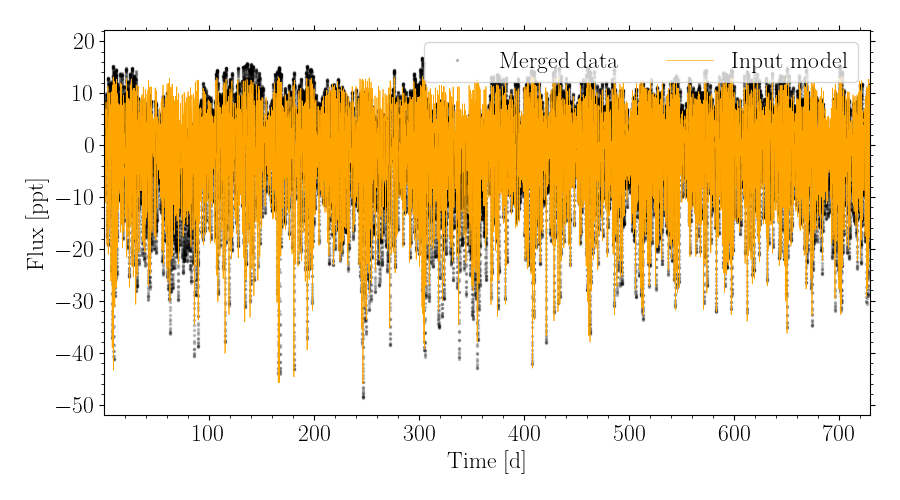

In [59]:
fig, ax = lc.plot(input_model=True, flux_unit='ppt', figsize=(9,5));

## Test frequency extraction with STARSHADOW

With a PLATOnium conda environment activated, first install software using
```
pip install git+https://github.com/LucIJspeert/star_shadow
```
Open the file needed to compile the `numba` code
```
$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Replace the line:
```
data_dir = script_dir.replace('star_shadow', 'data') 
```
with 
```
data_dir = os.path.join(script_dir, 'data')
```
Check that the `data` folder exists within the directory `$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow`. If not, create this directory and download and place the two files `sim_000_lc.dat` and `mpl_stylesheet.dat` into this folder.

Compile the code with:
```
python $CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Now the code can be used.

In [179]:
# import star_shadow as ss
# path = '/lhome/nicholas/software/workdir/mocka/test_vsc'
# filename = f'{path}/varsource/000000001/varsource_001.txt'
# df = pd.read_csv(filename, sep=' ', names=['time', 'mag'])

In [45]:
# df.time /= 86400.
# df['flux'] = ut.fromMagToFlux(df.mag)
# df.flux = (df.flux - df.flux.mean())
# df['flux_err'] = np.ones_like(df.flux)
# df = df.drop(columns=['mag'])
# df = df.loc[::24]  # 600s / 25s-> 24 exp
# df.to_csv(f'{path}/varsource_600s.dat', sep=' ', index=False, header=False)

In [44]:
# plt.figure(figsize=(9,5))
# plt.plot(df.time, df.flux, ',', alpha=0.5);

In [5]:
# ss.analyse_lc_from_file(f'{path}/varsource_600s.dat', save_dir=path, stage='freq', overwrite=True, verbose=True)

## Optimal SNR to extract modes

In [4]:
path = '/lhome/nicholas/software/workdir/mocka/snr'

In [139]:
# dx = snr_noise_peak(path, mag=9, cadence=1800, N=1000)

<IPython.core.display.Javascript object>


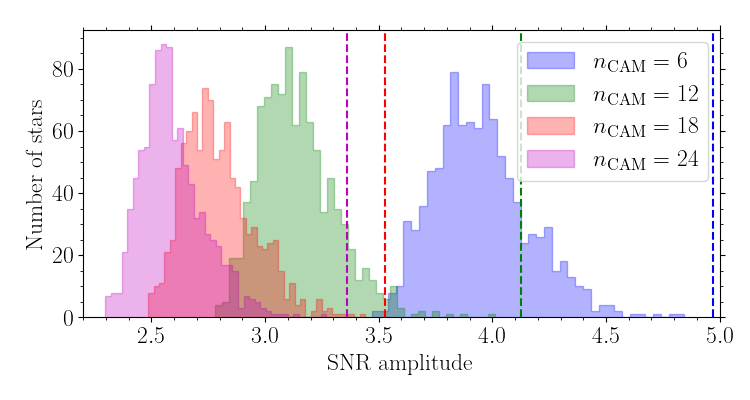

[4.970825948775678, 4.124219524660022, 3.526965771253316, 3.3592951717158304]


In [25]:
fig, ax = ut.snr_plot(path, mag=11, cadence=1800, bins=40, sigma=2, show_snr=True, figsize=(7.5,4))
ax.set_xlim(2.2, 5.0)
fig.savefig(f'{fdir}/OptimalCriterionSNR.png', bbox_inches='tight', dpi=300)


In [8]:
dex = 1 # magnitude index
cadence = 1800
mag = np.array([9, 11, 13, 15])
path = '/lhome/nicholas/software/workdir/mocka/snr'
N = 1000

noise_jitter     = ut.getJitterNoiseLimitNSR(rms=0.037, tdur=cadence, level='camera')
noise_photon_06  = ut.getPhotonNoiseLimitNSR(mag, passband='V', tdur=cadence, ncam=6)  * 0.7324478224428527
noise_photon_12  = ut.getPhotonNoiseLimitNSR(mag, passband='V', tdur=cadence, ncam=12) * 0.7324478224428527
noise_photon_18  = ut.getPhotonNoiseLimitNSR(mag, passband='V', tdur=cadence, ncam=18) * 0.7324478224428527
noise_photon_24  = ut.getPhotonNoiseLimitNSR(mag, passband='V', tdur=cadence, ncam=24) * 0.7324478224428527
noise_background = ut.getBackgroundNoiseLimitNSR(mag, tdur=cadence, passband='P')

noise_06 = noise_jitter + noise_photon_06 + noise_background
noise_12 = noise_jitter + noise_photon_12 + noise_background
noise_18 = noise_jitter + noise_photon_18 + noise_background
noise_24 = noise_jitter + noise_photon_24 + noise_background

df = pd.DataFrame()
df['mag']   = mag
df['NSR06'] = noise_06
df['NSR12'] = noise_12
df['NSR18'] = noise_18
df['NSR24'] = noise_24
df

,mag,NSR06,NSR12,NSR18,NSR24
0,9,55.662231,43.721459,38.431501,35.278058
1,11,149.133924,119.140060,105.852286,97.931196
2,13,471.029611,395.688433,362.311052,342.414175
3,15,1736.730716,1547.482233,1463.642044,1413.663348


In [91]:
time = np.arange(0, 4*365.25, cadence/86400.)
snr = np.zeros((N, 4))

for i in tqdm(range(N), bar_format=ut.tqdmBar()):
    
    # Noise time series
    lc_noise_06 = np.random.normal(0, noise_06[dex], len(time)) 
    lc_noise_12 = np.random.normal(0, noise_12[dex], len(time)) 
    lc_noise_18 = np.random.normal(0, noise_18[dex], len(time)) 
    lc_noise_24 = np.random.normal(0, noise_24[dex], len(time)) 

    # Estimate SNR of frequency of maximum power
    _, snr[i, 0], _ = extract_single(time, lc_noise_06, f0=0, fn=0, select='sn', verbose=True)
    _, snr[i, 1], _ = extract_single(time, lc_noise_12, f0=0, fn=0, select='sn', verbose=True)
    _, snr[i, 2], _ = extract_single(time, lc_noise_18, f0=0, fn=0, select='sn', verbose=True)
    _, snr[i, 3], _ = extract_single(time, lc_noise_24, f0=0, fn=0, select='sn', verbose=True)
    
filename = f'{path}/snr_{cadence}s_{df.mag.iloc[dex]}mag.ftr'
dx = pd.DataFrame({'snr06':snr[:,0], 'snr12':snr[:,1], 'snr18':snr[:,2], 'snr24':snr[:,3]})
# dx.to_feather(filename)

100%|██████████████████████████████████████████████████| 100/100 [11:50<00:00,  7.10s/it]            


<IPython.core.display.Javascript object>


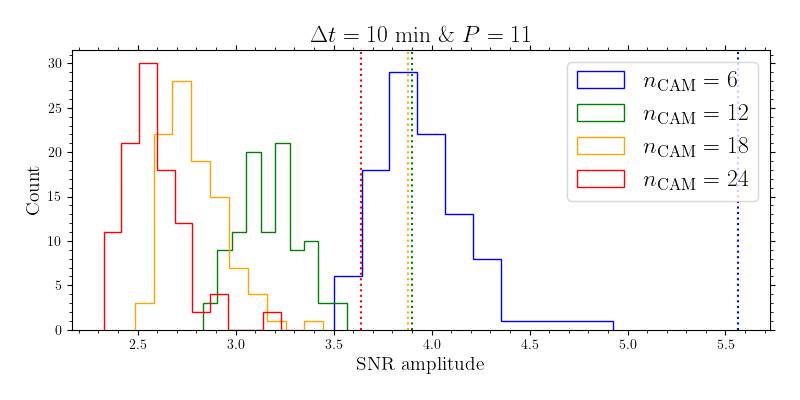

In [93]:
dx = pd.read_feather(filename)

# Inspect magnitude counts
fig, ax = plt.subplots(1,1, figsize=(8,4))
n = 10
sigma = 3
# Plots
h1 = ax.hist(dx.snr06, bins=n, histtype='step', label=r'$n_{\rm CAM} = 6$',   ec='blue')
h2 = ax.hist(dx.snr12, bins=n, histtype='step', label=r'$n_{\rm CAM} = 12$',  ec='green')
h3 = ax.hist(dx.snr18, bins=n, histtype='step', label=r'$n_{\rm CAM} = 18$',  ec='orange')
h4 = ax.hist(dx.snr24, bins=n, histtype='step', label=r'$n_{\rm CAM} = 24$',  ec='red')
val = [h1[1].mean() + sigma*h1[1].std(), h2[1].mean() + sigma*h2[1].std(), 
       h3[1].mean() + sigma*h3[1].std(), h4[1].mean() + sigma*h4[1].std()]
ax.axvline(x=val[0], c="blue",   ls=":", lw=1.5, zorder=2)
ax.axvline(x=val[1], c="green",  ls=":", lw=1.5, zorder=2)
ax.axvline(x=val[2], c="orange", ls=":", lw=1.5, zorder=2)
ax.axvline(x=val[3], c="red",    ls=":", lw=1.5, zorder=2)
# Settings
ax.legend(loc='best')
ax.set_title(f'$\Delta t = 10$ min \& $P={df.mag.iloc[dex]}$')
ax.set_xlabel(r'SNR amplitude')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [89]:
val

4.941001142599891

<IPython.core.display.Javascript object>


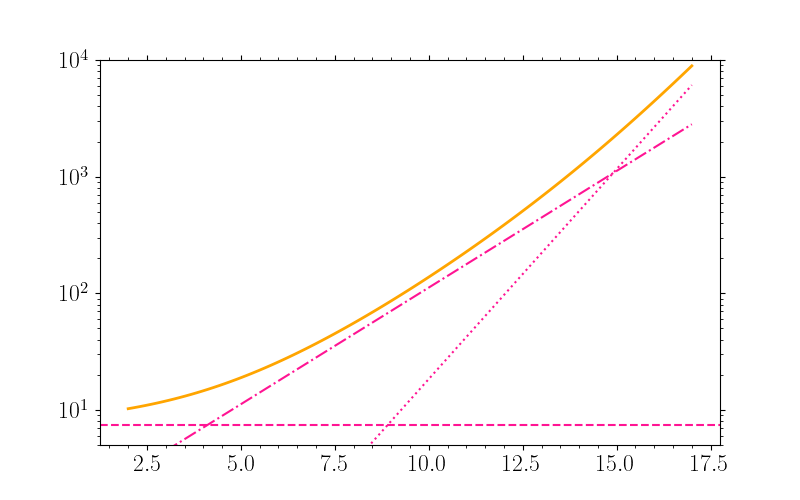

(5, 10000)

In [46]:
mag = np.linspace(2, 17, 100)
noise_jitter = ut.getJitterNoiseLimitNSR(rms=0.037, level='camera')
noise_photon = ut.getPhotonNoiseLimitNSR(mag, passband='V', ncam=1) * 0.7324478224428527
noise_background = ut.getBackgroundNoiseLimitNSR(mag, passband='P')
noise = noise_jitter + noise_photon + noise_background

fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.plot(mag, noise, '-', c='orange', lw=2,  zorder=2)
ax.plot(mag, noise_background, ':', c='deeppink', lw=1.5, zorder=2)
ax.plot(mag, noise_photon, '-.', c='deeppink', lw=1.5)
ax.axhline(y=noise_jitter, c="deeppink", ls="--", lw=1.5, zorder=2)
ax.set_yscale('log')
ax.set_ylim(5, 10000)

## Compare input and output

In [7]:
# Load star results
star = f'{1}'.zfill(9)
path = '/lhome/nicholas/software/workdir/mocka'
dp = pd.read_feather(f'{path}/test_vsc/varsource/{star}/varsource_001_parameters.ftr')
df = pd.read_feather(f'{path}/test_vsc/varsource/{star}/varsource_001_pulsations.ftr')
dm = pd.read_feather(f'{path}/test_vsc/finals_affogato/modes/modes_{star}.ftr')

# Correct for gamma factor
dm.ampl /= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = dm0.freq.to_numpy() - df0.freq.to_numpy()
A_oc = dm0.ampl.to_numpy() - df0.ampl.to_numpy()

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

FileNotFoundError: [Errno 2] No such file or directory: '/lhome/nicholas/software/workdir/mocka/test_vsc/varsource/000000001/varsource_001_parameters.ftr'

<IPython.core.display.Javascript object>


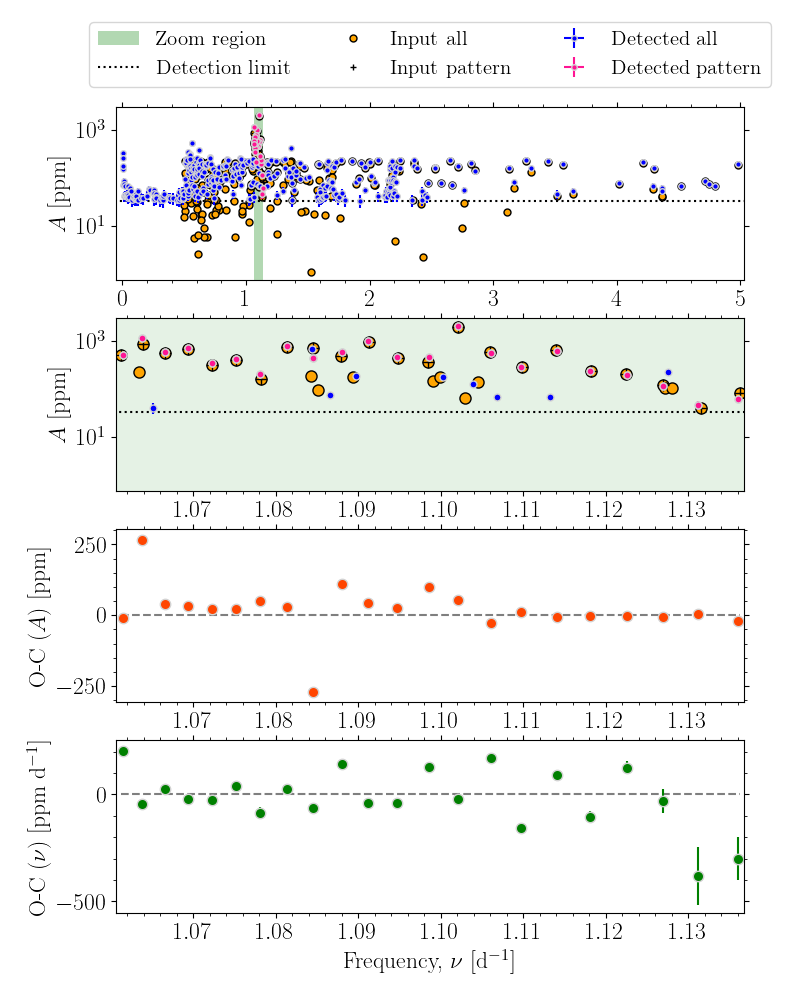

In [13]:
fig, ax = plt.subplots(4, 1, figsize=(8,10))

xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_yscale('log')
ax[1].set_xlim(xlim1[1], xlim1[0])

ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[2].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, mec='lightgray', color="orangered")
ax[2].set_ylabel(r'O-C ($A$) [ppm]')
ax[2].set_xlim(xlim1[1], xlim1[0])

ax[3].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, mec='lightgray', color="g")
ax[3].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[3].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[3].set_xlim(xlim1[1], xlim1[0])

plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

In [46]:
# fig, ax = plt.subplots(3, 1, figsize=(8,8))

# xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
# xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

# ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
# ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
# ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
# ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
# ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
# ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
# ax[0].set_ylabel(r'$A$ [ppm]')
# ax[0].set_yscale('log')
# ax[0].set_xlim(xlim0)

# ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
# ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
# ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
# ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
# ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
# ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
# ax[1].set_ylabel(r'$A$ [ppm]')
# ax[1].set_yscale('log')
# ax[1].set_xlim(xlim1[1], xlim1[0])

# ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
# ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
# ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
# ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
# ax[2].set_xlim(xlim1[1], xlim1[0])

# plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)